Dataset Summary:
      Set  Class  Count
0  train   bird   1414
1  train  drone   1248
2  valid   bird    217
3  valid  drone    225
4   test   bird    121
5   test  drone     94


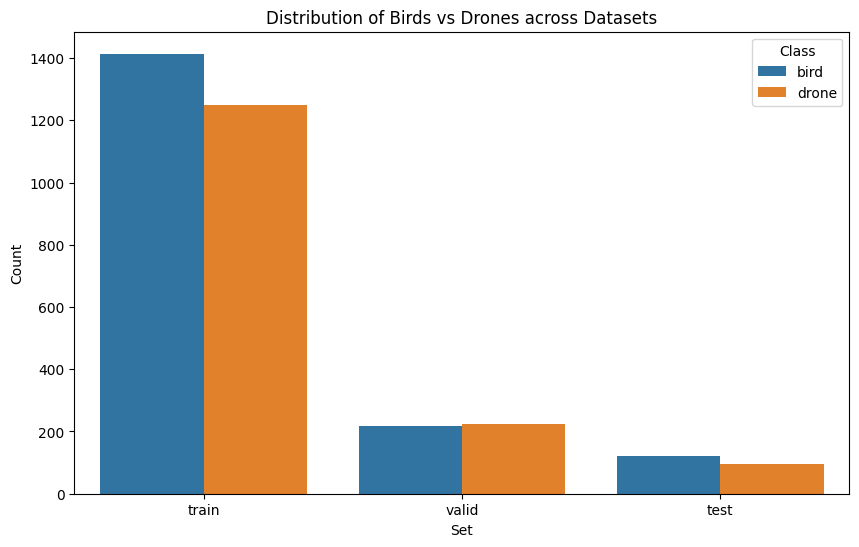

In [1]:
# 1. Dataset Inspection & Class Imbalance      -        Understand the Dataset

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define your dataset path
base_dir = 'D:/Python_Code/Projects_In_Course_Time/Project-5_AerialObjectClassification&Detection/' # Update this to your local path
sets = ['train', 'valid', 'test']
classes = ['bird', 'drone']

# 1. Inspect Folder Structure & Check Numbers
data_counts = []

for s in sets:
    for c in classes:
        path = os.path.join(base_dir, s, c)
        count = len(os.listdir(path))
        data_counts.append({'Set': s, 'Class': c, 'Count': count})

df = pd.DataFrame(data_counts)
print("Dataset Summary:\n", df)

# 2. Identify Class Imbalance (Visualization)
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Set', y='Count', hue='Class')
plt.title('Distribution of Birds vs Drones across Datasets')
plt.show()

In [3]:
!pip install opencv-python

   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
    --------------------------------------- 0.5/40.2 MB 4.6 MB/s eta 0:00:09
   - -------------------------------------- 1.6/40.2 MB 4.6 MB/s eta 0:00:09
   -- ------------------------------------- 2.4/40.2 MB 4.5 MB/s eta 0:00:09
   --- ------------------------------------ 3.1/40.2 MB 4.3 MB/s eta 0:00:09
   ---- ----------------------------------- 4.2/40.2 MB 4.2 MB/s eta 0:00:09
   ---- ----------------------------------- 4.7/40.2 MB 4.1 MB/s eta 0:00:09
   ----- ---------------------------------- 5.8/40.2 MB 4.1 MB/s eta 0:00:09
   ------ --------------------------------- 6.6/40.2 MB 4.1 MB/s eta 0:00:09
   ------- -------------------------------- 7.3/40.2 MB 4.1 MB/s eta 0:00:09
   -------- ------------------------------- 8.1/40.2 MB 4.1 MB/s eta 0:00:08
   -------- ------------------------------- 8.9/40.2 MB 4.0 MB/s eta 0:00:08
   --------- ------------------------------ 9.7/40.2 MB 4.0 MB/s eta 0:00:08
   ---

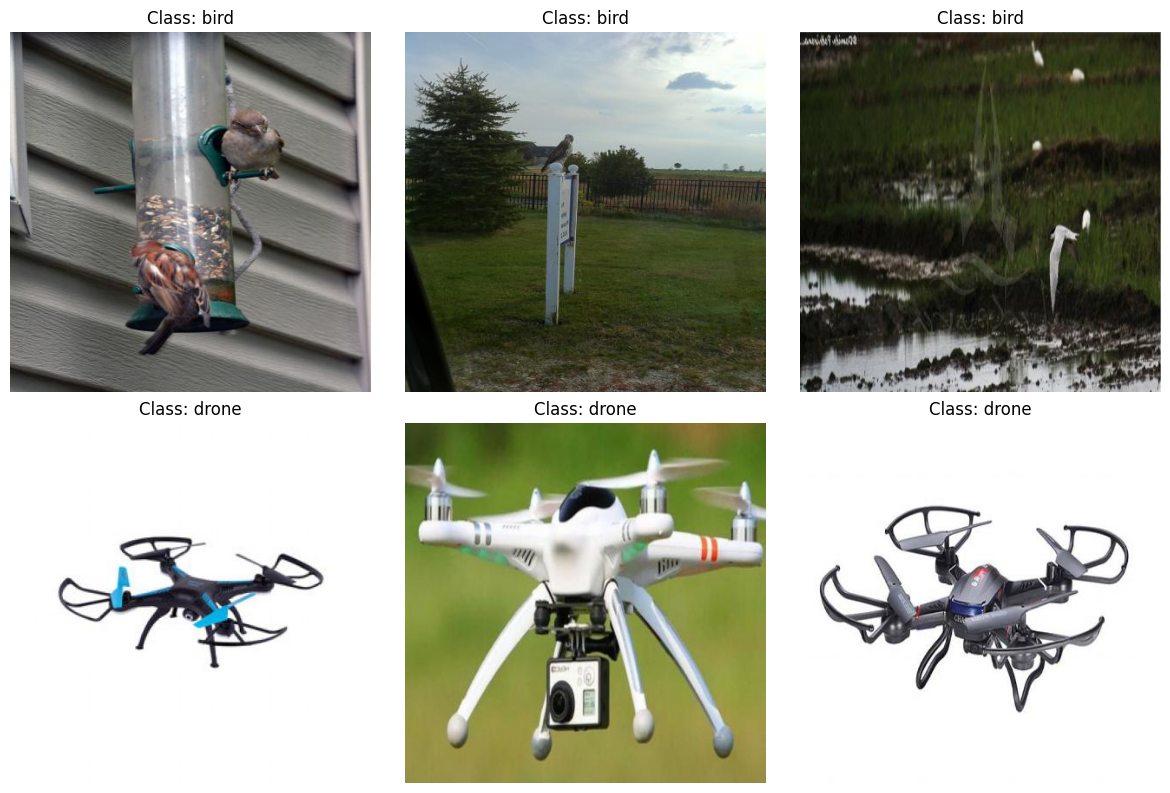

In [4]:
# 2. Visualize Sample Images

import cv2
import random

def visualize_samples(base_path, set_type='train', num_samples=3):
    plt.figure(figsize=(12, 8))
    
    for i, label in enumerate(classes):
        folder_path = os.path.join(base_path, set_type, label)
        sample_images = random.sample(os.listdir(folder_path), num_samples)
        
        for j, img_name in enumerate(sample_images):
            plt.subplot(len(classes), num_samples, i * num_samples + j + 1)
            img_path = os.path.join(folder_path, img_name)
            
            # Load and convert BGR to RGB
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            plt.imshow(img)
            plt.title(f"Class: {label}")
            plt.axis('off')
            
    plt.tight_layout()
    plt.show()

# Run the visualization
visualize_samples(base_dir)

In [5]:
import os

def list_files(startpath):
    for root, dirs, files in os.walk(startpath):
        # Calculate the depth to indent the output
        level = root.replace(startpath, '').count(os.sep)
        indent = ' ' * 4 * (level)
        # Print the directory name
        print(f"{indent}{os.path.basename(root)}/")
        subindent = ' ' * 4 * (level + 1)
        # Optionally show the count of files in that folder instead of listing every file
        if files:
            print(f"{subindent}({len(files)} images)")

# Replace with the actual path to your downloaded dataset
dataset_path = 'D:/Python_Code/Projects_In_Course_Time/Project-5_AerialObjectClassification&Detection/'
list_files(dataset_path)

/
    (6 images)
.ipynb_checkpoints/
    (1 images)
test/
    bird/
        (121 images)
    drone/
        (94 images)
train/
    bird/
        (1414 images)
    drone/
        (1248 images)
valid/
    bird/
        (217 images)
    drone/
        (225 images)


In [6]:
# 2. Data Preprocessing

# Implementation: TensorFlow/Keras Approach

import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array, load_img

def preprocess_tf(image_path):
    # 1. Resize images to 224x224 
    img = load_img(image_path, target_size=(224, 224))
    
    # 2. Convert to array
    img_array = img_to_array(img)
    
    # 3. Apply model-specific scaling and normalization [cite: 43, 47]
    # For many models, this handles the [0, 1] or [-1, 1] scaling automatically
    img_preprocessed = preprocess_input(img_array)
    
    return img_preprocessed

ModuleNotFoundError: No module named 'tensorflow'

In [1]:
#!pip install tensorflow
import sys
!{sys.executable} -m pip install tensorflow


ERROR: Could not find a version that satisfies the requirement tensorflow (from versions: none)
ERROR: No matching distribution found for tensorflow


In [2]:
import platform
import struct

print(f"Python Version: {platform.python_version()}")
print(f"Architecture: {struct.calcsize('P') * 8}-bit")

Python Version: 3.14.0
Architecture: 64-bit


In [4]:
!pip install tensorflow ipykernel matplotlib


ERROR: Could not find a version that satisfies the requirement tensorflow (from versions: none)
ERROR: No matching distribution found for tensorflow


In [5]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
# This should now work without the ModuleNotFoundError

ModuleNotFoundError: No module named 'tensorflow'

In [7]:
# Implementation: PyTorch Approach

from torchvision import transforms

# ImageNet normalization constants 
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# Define the preprocessing pipeline
preprocess_torch = transforms.Compose([
    # Resize to 224x224 
    transforms.Resize((224, 224)),
    # Convert to tensor and scale pixels to [0, 1] 
    transforms.ToTensor(),
    # Apply ImageNet normalization 
    transforms.Normalize(mean=mean, std=std)
])

ModuleNotFoundError: No module named 'torchvision'

In [ ]:
#  3. Data Augmentation

# Implementation: TensorFlow/Keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Initialize the generator with the required transformations 
train_datagen = ImageDataGenerator(
    rescale=1./255,           # Preprocessing: Normalization [cite: 43]
    rotation_range=30,        # Transformation: Rotation 
    width_shift_range=0.2,    # Transformation: Horizontal Shifting
    height_shift_range=0.2,   # Transformation: Vertical Shifting
    shear_range=0.2,          # Transformation: Cropping/Shearing 
    zoom_range=0.2,           # Transformation: Zoom 
    horizontal_flip=True,     # Transformation: Flipping 
    brightness_range=[0.8, 1.2], # Transformation: Brightness 
    fill_mode='nearest'       # Strategy to fill pixels lost during rotation
)

# Apply to your training folder [cite: 38, 103]
train_generator = train_datagen.flow_from_directory(
    'dataset/train',
    target_size=(224, 224),   # Standardized size [cite: 44]
    batch_size=32,
    class_mode='binary'       # Bird or Drone [cite: 97]
)

In [ ]:
#  Implementation: PyTorch

from torchvision import transforms

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),            # Preprocessing [cite: 44]
    transforms.RandomRotation(30),            # Rotation 
    transforms.RandomHorizontalFlip(),        # Flipping 
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)), # Cropping/Zoom 
    transforms.ColorJitter(brightness=0.2),   # Brightness 
    transforms.ToTensor(),                    # Normalization [cite: 43]
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # 
])

In [6]:
# Streamlit Application Code (app.py)

import streamlit as st
import tensorflow as tf
from ultralytics import YOLO
from PIL import Image
import numpy as np

# --- 1. Load Models ---
@st.cache_resource # Keeps models in memory for speed
def load_models():
    # Load your saved classification model (Step 7)
    classifier = tf.keras.models.load_model('best_bird_drone_model.h5')
    # Load your trained YOLOv8 model (Step 8)
    detector = YOLO('runs/detect/bird_drone_detection/weights/best.pt') 
    return classifier, detector

classifier, detector = load_models()

# --- 2. Simple UI ---
st.title("🦅 Aerial Object Sentinel")
st.write("Upload an aerial image to classify and detect Birds vs. Drones.")

uploaded_file = st.file_uploader("Choose an image...", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
    # Display the uploaded image
    image = Image.open(uploaded_file)
    st.image(image, caption='Uploaded Image', use_container_width=True)
    
    st.write("---")
    col1, col2 = st.columns(2)

    # --- 3. Run Classification (Step 4 & 6) ---
    with col1:
        st.subheader("Classification Results")
        # Preprocess for CNN (Resize 224x224 & Normalize [0,1])
        img_resized = image.resize((224, 224))
        img_array = np.array(img_resized) / 255.0
        img_array = np.expand_dims(img_array, axis=0)
        
        prediction = classifier.predict(img_array)[0][0]
        label = "Drone" if prediction > 0.5 else "Bird"
        confidence = prediction if label == "Drone" else (1 - prediction)
        
        st.metric(label=f"Detected: {label}", value=f"{confidence*100:.2f}% Confidence")

    # --- 4. Run YOLOv8 Detection (Optional Step) ---
    with col2:
        st.subheader("Object Detection")
        # Run YOLO inference
        results = detector(image)
        
        # Plot results back onto the image
        res_plotted = results[0].plot()
        st.image(res_plotted, caption='YOLOv8 Bounding Boxes', use_container_width=True)

ModuleNotFoundError: No module named 'tensorflow'